In [2]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from __future__ import annotations
import os
from dataclasses import dataclass, field
from typing import Callable, Sequence
from scipy import stats

import smoothie
smoothie.suppress_warnings()

### LOAD DATA

In [3]:
adata_bin50_human = ad.read_h5ad(
    "../data/GSM9629357_CS23_E2S1_bin50.h5ad"
)
print(adata_bin50_human.shape)

adata_bin50_mouse = ad.read_h5ad(
    "../data/E16.5_E1S1.MOSTA.h5ad"
)
print(adata_bin50_mouse.shape)

(662769, 49848)
(121767, 28204)


### QC + NORM

In [5]:
# Data already normalized! - just remove sparse genes
sc.pp.filter_genes(adata_bin50_human, min_cells=50)
print(adata_bin50_human.shape)

# Data already normalized! - just remove sparse genes
sc.pp.filter_genes(adata_bin50_mouse, min_cells=50)
print(adata_bin50_mouse.shape)

(662769, 32266)
(121767, 21383)


### SMOOTHING

In [4]:
# human
# target_microns = 30.0
# micron_to_unit_conversion = 2
# sm_adata_bin50_human = smoothie.run_parallelized_smoothing(
#     adata_bin50_human,
#     grid_based_or_not=False,
#     gaussian_sd=target_microns * micron_to_unit_conversion,
#     min_spots_under_gaussian=5
# )
# sm_adata_bin50_human.write_h5ad("../data/sm_adata/human_GSM9629357_CS23_E2S1_bin50_sm.h5ad") #save

sm_adata_bin50_human = ad.read_h5ad("../data/sm_adata/human_GSM9629357_CS23_E2S1_bin50_sm.h5ad")

# # mouse
# target_microns = 30.0
# micron_to_unit_conversion = (1.0 / 25.0)
# sm_adata_bin50_mouse = smoothie.run_parallelized_smoothing(
#     adata_bin50_mouse,
#     grid_based_or_not=False,
#     gaussian_sd=target_microns * micron_to_unit_conversion,
#     min_spots_under_gaussian=5
# )
# sm_adata_bin50_mouse.write_h5ad("../data/sm_adata/mouse_E1S1_165_bin50_sm.h5ad") #save

sm_adata_bin50_mous = ad.read_h5ad("../data/sm_adata/mouse_E1S1_165_bin50_sm.h5ad")

### PEARSON R CALCULATION

In [6]:
# human
# pearsonR_mat_bin50_human, pval_mat_bin50_human = smoothie.compute_correlation_matrix(sm_adata_bin50_human.X)
# geneNames_bin50_human = sm_adata_bin50_human.var_names.to_numpy()
# np.save(f"../data/pearsonR/human_GSM9629357_CS23_E2S1_bin50_pearsonR.npy", pearsonR_mat_bin50_human)
# np.save(f"../data/pearsonR/human_GSM9629357_CS23_E2S1_bin50_gene_names.npy", geneNames_bin50_human)

pearsonR_mat_bin50_human = np.load("../data/pearsonR/human_GSM9629357_CS23_E2S1_bin50_pearsonR.npy", allow_pickle = True)
geneNames_bin50_human = np.load("../data/pearsonR/human_GSM9629357_CS23_E2S1_bin50_gene_names.npy", allow_pickle = True)

# mouse
# pearsonR_mat_bin50_mouse, pval_mat_bin50_mouse = smoothie.compute_correlation_matrix(sm_adata_bin50_mouse.X)
# geneNames_bin50_mouse = sm_adata_bin50_mouse.var_names.to_numpy()
# np.save(f"../data/pearsonR/mouse_E1S1_165_bin50_pearsonR.npy", pearsonR_mat_bin50_mouse)
# np.save(f"../data/pearsonR/mouse_E1S1_165_bin50_gene_names.npy", geneNames_bin50_mouse)

pearsonR_mat_bin50_mouse = np.load("../data/pearsonR/mouse_E1S1_165_bin50_pearsonR.npy", allow_pickle = True)
geneNames_bin50_mouse = np.load("../data/pearsonR/mouse_E1S1_165_bin50_gene_names.npy", allow_pickle = True)

### Pearson R Matrix Integration

In [7]:
"""
ortholog_align.py — align two gene x gene correlation matrices on 1-to-1 orthologs.

Given two square gene correlation matrices (one per species), their gene-name
lists, and an MGI/Alliance-style vertebrate homology table, this builds the set
of 1-to-1 orthologs actually present in both matrices and returns symmetrically
permuted matrices whose first X rows/cols are those orthologs in identical order.
Remaining genes are appended in their original order.

Typical notebook use
--------------------
    import numpy as np
    from ortholog_align import load_homology, align_matrices, save_aligned

    hom = load_homology("HOM_AllOrganism.rpt")

    res = align_matrices(
        mat_a=corr_mouse, genes_a=genes_mouse, species_a="mouse, laboratory",
        mat_b=corr_human, genes_b=genes_human, species_b="human",
        hom=hom,
    )
    res.summary()
    res.pairs.head()
    res.rejects.query("reason == 'multi_paralog_in_matrix'")

    save_aligned(res, "out/", name_a="mouse", name_b="human")

Design notes
------------
* 1-to-1 is evaluated *after* intersecting with the matrix gene lists, so a class
  with two paralogs in the table but only one in the matrix is usable. The strict
  table-only count is reported alongside for comparison.
* A symbol landing in more than one retained homology class is dropped — that is
  not 1-to-1 regardless of per-class counts.
* Duplicate gene symbols within a matrix gene list are dropped, never take-first.
"""

CLASS_COL = "DB Class Key"
ORG_COL = "Common Organism Name"
TAXON_COL = "NCBI Taxon ID"
SYMBOL_COL = "Symbol"
ENTREZ_COL = "EntrezGene ID"


def _norm(s: str) -> str:
    """Default symbol normalizer for cross-referencing table <-> matrix."""
    return str(s).strip().upper()


# ---------------------------------------------------------------- homology table


def load_homology(path: str, sep: str = "\t") -> pd.DataFrame:
    """Read the homology report, keeping everything as stripped strings."""
    hom = pd.read_csv(path, sep=sep, dtype=str, keep_default_na=False)
    missing = {CLASS_COL, ORG_COL, TAXON_COL, SYMBOL_COL} - set(hom.columns)
    if missing:
        raise ValueError(f"homology table missing columns: {sorted(missing)}")
    for col in hom.columns:
        hom[col] = hom[col].str.strip()
    return hom[hom[SYMBOL_COL] != ""].copy()


def _resolve_species(hom: pd.DataFrame, key: str | int) -> str:
    """Accept a taxon ID or a common organism name; return the taxon ID."""
    key = str(key).strip()
    if key in set(hom[TAXON_COL]):
        return key
    hits = sorted(set(hom.loc[hom[ORG_COL].str.lower() == key.lower(), TAXON_COL]))
    if len(hits) == 1:
        return hits[0]
    if not hits:
        names = sorted(set(hom[ORG_COL]))
        raise ValueError(f"species {key!r} not found. Available: {names}")
    raise ValueError(f"species {key!r} maps to multiple taxon IDs: {hits}")


# ---------------------------------------------------------------- gene lists


def _matrix_index(
    genes: Sequence[str], normalize: Callable[[str], str]
) -> tuple[dict[str, str], list[str]]:
    """Map normalized symbol -> original name. Symbols colliding are excluded."""
    counts: dict[str, int] = {}
    first: dict[str, str] = {}
    for g in genes:
        k = normalize(g)
        counts[k] = counts.get(k, 0) + 1
        first.setdefault(k, g)
    dupes = sorted(k for k, n in counts.items() if n > 1)
    lookup = {k: v for k, v in first.items() if counts[k] == 1}
    return lookup, dupes


# ---------------------------------------------------------------- ortholog logic


def one_to_one_orthologs(
    hom: pd.DataFrame,
    species_a: str | int,
    species_b: str | int,
    genes_a: Sequence[str] | None = None,
    genes_b: Sequence[str] | None = None,
    normalize: Callable[[str], str] = _norm,
    strict_multiclass: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build the 1-to-1 ortholog table, optionally restricted to matrix genes.

    Returns (pairs, rejects). If genes_a/genes_b are None, the result is the
    strict table-only 1-to-1 set.

    strict_multiclass
        If True (default), a gene is disqualified up front when its symbol
        appears under more than one DB Class Key for its own species anywhere in
        the table — regardless of what the other species contributes to those
        classes. This is evaluated before per-class counting, so removing an
        ambiguous gene can leave a sibling class cleanly 1-to-1.
        If False, only classes retained in the final pair set are cross-checked
        for repeated symbols, which lets an ambiguous gene survive whenever its
        competing classes happen to fail for some other reason.

        Ambiguity is judged on the normalized symbol, matching how genes are
        looked up in the matrix: two table symbols that normalize to the same
        string are indistinguishable downstream, so both are excluded.
    """
    tax_a, tax_b = _resolve_species(hom, species_a), _resolve_species(hom, species_b)
    if tax_a == tax_b:
        raise ValueError("species_a and species_b resolve to the same taxon")

    lookup_a, dup_a = (
        _matrix_index(genes_a, normalize) if genes_a is not None else (None, [])
    )
    lookup_b, dup_b = (
        _matrix_index(genes_b, normalize) if genes_b is not None else (None, [])
    )

    cols = [CLASS_COL, TAXON_COL, SYMBOL_COL]
    if ENTREZ_COL in hom.columns:
        cols.append(ENTREZ_COL)
    sub = hom.loc[hom[TAXON_COL].isin({tax_a, tax_b}), cols].copy()
    sub["_side"] = np.where(sub[TAXON_COL].values == tax_a, "a", "b")
    sub["_n"] = sub[SYMBOL_COL].map(normalize)

    rejects: list[tuple] = []

    def _log(frame, reason):
        """Append one reject row per (class, side) with its symbols joined."""
        if frame.empty:
            return
        g = frame.groupby([CLASS_COL, "_side"], sort=False)[SYMBOL_COL].agg(
            lambda s: ";".join(sorted(set(s)))
        )
        for (ck, side), syms in g.items():
            rejects.append((ck, side, syms, reason))

    if strict_multiclass:
        nclass = sub.groupby(["_side", "_n"], sort=False)[CLASS_COL].transform("nunique")
        amb = nclass.values > 1
        if amb.any():
            bad = sub[amb]
            g = bad.groupby(["_side", "_n"], sort=False).agg(
                cks=(CLASS_COL, lambda s: ";".join(sorted(set(s)))),
                syms=(SYMBOL_COL, lambda s: ";".join(sorted(set(s)))),
            )
            for (side, _), row in g.iterrows():
                rejects.append((row["cks"], side, row["syms"], "symbol_in_multiple_classes"))
            sub = sub[~amb]

    classes = pd.Index(sub[CLASS_COL].unique(), name=CLASS_COL)

    def _counts(frame):
        c = frame.groupby([CLASS_COL, "_side"], sort=False).size().unstack(fill_value=0)
        for s in ("a", "b"):
            if s not in c.columns:
                c[s] = 0
        return c.reindex(classes, fill_value=0)

    pre = _counts(sub)

    if lookup_a is not None or lookup_b is not None:
        drop = np.zeros(len(sub), dtype=bool)
        side_arr = sub["_side"].values
        for side, lookup in (("a", lookup_a), ("b", lookup_b)):
            if lookup is None:
                continue
            drop |= (side_arr == side) & ~sub["_n"].isin(lookup).values
        subf = sub[~drop]
    else:
        subf = sub
    post = _counts(subf)

    for side, lookup in (("a", lookup_a), ("b", lookup_b)):
        absent = classes[pre[side].values == 0]
        rejects.extend((ck, side, "", "absent_from_class") for ck in absent)

        if lookup is not None:
            gone = classes[(pre[side].values > 0) & (post[side].values == 0)]
            _log(sub[sub[CLASS_COL].isin(gone) & (sub["_side"].values == side)],
                 "none_in_matrix")

        multi = classes[post[side].values > 1]
        reason = "multi_paralog_in_matrix" if lookup is not None else "multi_paralog_in_table"
        _log(subf[subf[CLASS_COL].isin(multi) & (subf["_side"].values == side)], reason)

    good = classes[(post["a"].values == 1) & (post["b"].values == 1)]
    gsub = subf[subf[CLASS_COL].isin(good)]
    side_frames = {}
    for side in ("a", "b"):
        f = gsub[gsub["_side"].values == side].set_index(CLASS_COL)
        side_frames[side] = f.reindex(good)

    pairs = pd.DataFrame({"class_key": np.asarray(good)})
    for side, lookup in (("a", lookup_a), ("b", lookup_b)):
        f = side_frames[side]
        pairs[f"symbol_{side}"] = f[SYMBOL_COL].values
        pairs[f"entrez_{side}"] = (
            f[ENTREZ_COL].values if ENTREZ_COL in f.columns else ""
        )
        norm = f["_n"].values
        pairs[f"matrix_name_{side}"] = (
            [lookup[k] for k in norm] if lookup is not None else f[SYMBOL_COL].values
        )
    pairs = pairs[
        [
            "class_key",
            "symbol_a",
            "entrez_a",
            "matrix_name_a",
            "symbol_b",
            "entrez_b",
            "matrix_name_b",
        ]
    ]

    # Safety net for strict_multiclass=False: a symbol reaching two retained classes.
    if not strict_multiclass and not pairs.empty:
        for side in ("a", "b"):
            key = pairs[f"symbol_{side}"].map(normalize)
            bad = set(key[key.duplicated(keep=False)])
            if bad:
                for _, r in pairs[key.isin(bad)].iterrows():
                    rejects.append(
                        (r["class_key"], side, r[f"symbol_{side}"], "symbol_in_multiple_classes")
                    )
                pairs = pairs[~key.isin(bad)]

    for side, dupes in (("a", dup_a), ("b", dup_b)):
        rejects.extend(("", side, d, "duplicate_symbol_in_matrix") for d in dupes)

    rejects_df = pd.DataFrame(
        rejects, columns=["class_key", "side", "symbols", "reason"]
    ).drop_duplicates()

    pairs = pairs.sort_values("class_key", key=lambda s: pd.to_numeric(s, errors="coerce"))
    return pairs.reset_index(drop=True), rejects_df.reset_index(drop=True)


# ---------------------------------------------------------------- robust filter


def max_offdiag(
    mat: np.ndarray, use_abs: bool = False, chunk: int = 1024
) -> np.ndarray:
    """Per-gene maximum correlation to any *other* gene.

    The diagonal is excluded so self-correlation never sets the value. NaNs are
    ignored; a gene whose entire row is NaN gets -inf and can never pass a
    threshold.

    Computed in row blocks and in the matrix's own dtype: a float32 20k x 20k
    input is never upcast or fully copied, which matters because a whole-matrix
    temporary at that size is 3.2 GB per copy.
    """
    mat = np.asarray(mat)
    n = mat.shape[0]
    if mat.ndim != 2 or mat.shape[1] != n:
        raise ValueError(f"matrix must be square, got {mat.shape}")
    dtype = mat.dtype if np.issubdtype(mat.dtype, np.floating) else np.float64

    out = np.empty(n, dtype=dtype)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        blk = mat[s:e].astype(dtype, copy=True)
        if use_abs:
            np.abs(blk, out=blk)
        blk[np.arange(e - s), np.arange(s, e)] = -np.inf
        nan = np.isnan(blk)
        if nan.any():
            np.copyto(blk, -np.inf, where=nan)
        out[s:e] = blk.max(axis=1)
    return out


def robust_subset(
    mat: np.ndarray,
    genes: Sequence[str],
    thresh: float | None,
    use_abs: bool = False,
) -> tuple[np.ndarray, list[str], np.ndarray, np.ndarray]:
    """Keep only genes whose max off-diagonal correlation exceeds `thresh`.

    Returns (submatrix, subgenes, kept_index, max_corr_of_kept). `thresh=None`
    is a no-op pass-through.

    Note the set is self-consistent for a symmetric matrix: if r(X,Y) clears the
    threshold then both X and Y clear it, so every retained gene keeps the
    partner that qualified it.
    """
    mat = np.asarray(mat)
    genes = list(genes)
    mx = max_offdiag(mat, use_abs=use_abs)
    if thresh is None:
        return mat, genes, np.arange(len(genes)), mx
    keep = np.flatnonzero(mx > thresh)
    return mat[np.ix_(keep, keep)], [genes[i] for i in keep], keep, mx[keep]


# ---------------------------------------------------------------- reordering


def order_index(
    genes: Sequence[str], lead_genes: Sequence[str], keep_rest: bool = True
) -> np.ndarray:
    """Positions of `lead_genes` first, then the rest in original order."""
    pos = {}
    for i, g in enumerate(genes):
        pos.setdefault(g, i)
    lead_idx = [pos[g] for g in lead_genes]
    if len(set(lead_idx)) != len(lead_idx):
        raise ValueError("lead_genes contains duplicate matrix positions")
    if not keep_rest:
        return np.asarray(lead_idx, dtype=int)
    used = set(lead_idx)
    rest = [i for i in range(len(genes)) if i not in used]
    return np.asarray(lead_idx + rest, dtype=int)


def reorder_matrix(
    mat: np.ndarray,
    genes: Sequence[str],
    lead_genes: Sequence[str],
    keep_rest: bool = True,
) -> tuple[np.ndarray, list[str], np.ndarray]:
    """Symmetrically permute `mat` so `lead_genes` occupy the first rows/cols."""
    mat = np.asarray(mat)
    genes = list(genes)
    if mat.ndim != 2 or mat.shape[0] != mat.shape[1]:
        raise ValueError(f"matrix must be square, got {mat.shape}")
    if mat.shape[0] != len(genes):
        raise ValueError(f"matrix is {mat.shape[0]}x{mat.shape[0]} but got {len(genes)} genes")

    idx = order_index(genes, lead_genes, keep_rest)
    return mat[np.ix_(idx, idx)], [genes[i] for i in idx], idx


# ---------------------------------------------------------------- pipeline


@dataclass
class AlignedPair:
    matrix_a: np.ndarray
    genes_a: list[str]
    matrix_b: np.ndarray
    genes_b: list[str]
    pairs: pd.DataFrame
    rejects: pd.DataFrame
    index_a: np.ndarray
    index_b: np.ndarray
    n_strict: int = 0
    max_corr_a: np.ndarray | None = None
    max_corr_b: np.ndarray | None = None
    n_input_a: int = 0
    n_input_b: int = 0
    meta: dict = field(default_factory=dict)

    @property
    def n_orthologs(self) -> int:
        return len(self.pairs)

    def summary(self) -> None:
        n = self.n_orthologs
        ta, tb = self.meta.get("pcc_thresh_a"), self.meta.get("pcc_thresh_b")
        if ta is not None or tb is not None:
            print(f"robust filter A (max r > {ta}): "
                  f"{self.meta.get('n_robust_a')} / {self.n_input_a} genes")
            print(f"robust filter B (max r > {tb}): "
                  f"{self.meta.get('n_robust_b')} / {self.n_input_b} genes")
        if self.n_strict:
            print(f"1-to-1 orthologs (table only):        {self.n_strict}")
        print(f"1-to-1 orthologs (robust in both):    {n}")
        print(f"  classes still multi-paralog:        "
              f"{(self.rejects.reason == 'multi_paralog_in_matrix').sum()}")
        print(f"matrix A: {self.matrix_a.shape}, first {n} rows/cols are orthologs")
        print(f"matrix B: {self.matrix_b.shape}, first {n} rows/cols are orthologs")
        print("\nrejection reasons:")
        print(self.rejects.reason.value_counts().to_string())

    def gene_table(self, side: str = "a") -> pd.DataFrame:
        """Per-gene table for one dataset, in final matrix order."""
        genes = self.genes_a if side == "a" else self.genes_b
        mx = self.max_corr_a if side == "a" else self.max_corr_b
        n = self.n_orthologs
        return pd.DataFrame(
            {
                "position": np.arange(len(genes)),
                "gene": genes,
                "max_corr": mx if mx is not None else np.nan,
                "in_ortholog_block": np.arange(len(genes)) < n,
            }
        )

    def check(self, tol: float = 1e-8) -> None:
        """Assert the ortholog blocks line up and symmetry survived."""
        n = self.n_orthologs
        assert self.genes_a[:n] == list(self.pairs.matrix_name_a), "block A misordered"
        assert self.genes_b[:n] == list(self.pairs.matrix_name_b), "block B misordered"
        rng = np.random.default_rng(0)
        for m, tag in ((self.matrix_a, "A"), (self.matrix_b, "B")):
            k = m.shape[0]
            if k == 0:
                continue
            # sampled rather than full: allclose on a 20k x 20k matrix allocates
            # several more copies of it just to answer a diagnostic question
            i = rng.choice(k, size=min(k, 512), replace=False)
            blk = m[np.ix_(i, i)]
            if np.allclose(blk, blk.T, atol=tol, equal_nan=True):
                continue
            print(f"note: matrix {tag} is not symmetric (permutation still valid)")
        print(f"OK — {n} aligned ortholog positions")


def align_matrices(
    mat_a: np.ndarray,
    genes_a: Sequence[str],
    species_a: str | int,
    mat_b: np.ndarray,
    genes_b: Sequence[str],
    species_b: str | int,
    hom: pd.DataFrame,
    keep_rest: bool = True,
    normalize: Callable[[str], str] = _norm,
    strict_multiclass: bool = True,
    pcc_thresh_a: float | None = None,
    pcc_thresh_b: float | None = None,
    use_abs: bool = False,
    report_strict: bool = True,
) -> AlignedPair:
    """Full pipeline: robust filter -> orthologs -> symmetric permutation.

    pcc_thresh_a / pcc_thresh_b
        Per-dataset cutoffs on each gene's maximum off-diagonal correlation.
        Genes at or below the cutoff are dropped from that dataset entirely, so
        the returned matrices are the "robust" submatrices. Ortholog matching
        then runs on the survivors, meaning the leading block is orthologs that
        are robust in *both* datasets and the tail is each dataset's remaining
        robust genes. `None` disables filtering for that dataset.

    use_abs
        Score on |r| instead of signed r, if strong anticorrelation should also
        qualify a gene as robust.

    report_strict
        Also compute the table-only 1-to-1 count for the summary. Set False to
        skip a second pass over the homology table.
    """
    n_in_a, n_in_b = len(genes_a), len(genes_b)

    def _prep(mat, genes, thresh):
        mx = max_offdiag(mat, use_abs=use_abs)
        keep = np.arange(len(genes)) if thresh is None else np.flatnonzero(mx > thresh)
        return mx, keep, [genes[i] for i in keep]

    mx_a, keep_a, rgenes_a = _prep(mat_a, genes_a, pcc_thresh_a)
    mx_b, keep_b, rgenes_b = _prep(mat_b, genes_b, pcc_thresh_b)

    kw = dict(normalize=normalize, strict_multiclass=strict_multiclass)
    n_strict = 0
    if report_strict:
        n_strict = len(one_to_one_orthologs(hom, species_a, species_b, **kw)[0])
    pairs, rejects = one_to_one_orthologs(
        hom, species_a, species_b, rgenes_a, rgenes_b, **kw
    )

    # One fused gather per matrix: robust filter and ortholog ordering combined,
    # so a large matrix is copied once rather than twice.
    loc_a = order_index(rgenes_a, list(pairs.matrix_name_a), keep_rest)
    loc_b = order_index(rgenes_b, list(pairs.matrix_name_b), keep_rest)
    idx_a, idx_b = keep_a[loc_a], keep_b[loc_b]

    new_a = np.asarray(mat_a)[np.ix_(idx_a, idx_a)]
    new_b = np.asarray(mat_b)[np.ix_(idx_b, idx_b)]
    ga = [rgenes_a[i] for i in loc_a]
    gb = [rgenes_b[i] for i in loc_b]

    return AlignedPair(
        matrix_a=new_a,
        genes_a=ga,
        matrix_b=new_b,
        genes_b=gb,
        pairs=pairs,
        rejects=rejects,
        index_a=idx_a,
        index_b=idx_b,
        n_strict=n_strict,
        max_corr_a=mx_a[idx_a],
        max_corr_b=mx_b[idx_b],
        n_input_a=n_in_a,
        n_input_b=n_in_b,
        meta={
            "species_a": str(species_a),
            "species_b": str(species_b),
            "keep_rest": keep_rest,
            "strict_multiclass": strict_multiclass,
            "pcc_thresh_a": pcc_thresh_a,
            "pcc_thresh_b": pcc_thresh_b,
            "use_abs": use_abs,
            "n_robust_a": len(rgenes_a),
            "n_robust_b": len(rgenes_b),
        },
    )


# ---------------------------------------------------------------- io


def save_aligned(
    res: AlignedPair, outdir: str, name_a: str = "a", name_b: str = "b"
) -> dict[str, str]:
    """Write matrices (.npy), gene lists (.txt), ortholog table and rejects (.tsv)."""
    os.makedirs(outdir, exist_ok=True)
    paths = {}

    for tag, mat, genes in ((name_a, res.matrix_a, res.genes_a), (name_b, res.matrix_b, res.genes_b)):
        mp = os.path.join(outdir, f"{tag}_corr_orthoaligned.npy")
        gp = os.path.join(outdir, f"{tag}_genes_orthoaligned.txt")
        np.save(mp, mat)
        with open(gp, "w") as fh:
            fh.write("\n".join(genes) + "\n")
        paths[f"{tag}_matrix"], paths[f"{tag}_genes"] = mp, gp

    for tag, side in ((name_a, "a"), (name_b, "b")):
        tp = os.path.join(outdir, f"{tag}_gene_table.tsv")
        res.gene_table(side).to_csv(tp, sep="\t", index=False)
        paths[f"{tag}_table"] = tp

    pp = os.path.join(outdir, "ortholog_pairs.tsv")
    rp = os.path.join(outdir, "ortholog_rejects.tsv")
    res.pairs.to_csv(pp, sep="\t", index=False)
    res.rejects.to_csv(rp, sep="\t", index=False)
    paths["pairs"], paths["rejects"] = pp, rp

    print(f"wrote {len(paths)} files to {outdir} "
          f"(n_orthologs={res.n_orthologs}, block = first {res.n_orthologs} rows/cols)")
    return paths

In [8]:
# Load ortholog list (Complete List of Vertebrate Homology Classes - https://www.informatics.jax.org/homology.shtml)
hom = load_homology("../data/HOM_AllOrganism.rpt")

In [9]:
res = align_matrices(
    mat_a=pearsonR_mat_bin50_mouse, genes_a=geneNames_bin50_mouse, species_a="mouse, laboratory", pcc_thresh_a=0.4,
    mat_b=pearsonR_mat_bin50_human, genes_b=geneNames_bin50_human, species_b="human", pcc_thresh_b=0.2,
    hom=hom, # homology table
    keep_rest=True,  # non-orthologs appended in original order
    strict_multiclass=True,  # orthologs can only be from the same DB Class Key
)
res.summary()
res.check()

robust filter A (max r > 0.4): 8283 / 21383 genes
robust filter B (max r > 0.2): 6780 / 32266 genes
1-to-1 orthologs (table only):        17159
1-to-1 orthologs (robust in both):    4169
  classes still multi-paralog:        26
matrix A: (8283, 8283), first 4169 rows/cols are orthologs
matrix B: (6780, 6780), first 4169 rows/cols are orthologs

rejection reasons:
reason
none_in_matrix                26302
absent_from_class              4376
symbol_in_multiple_classes     1198
multi_paralog_in_matrix          26
OK — 4169 aligned ortholog positions


### Stitch Profiles Together

In [10]:
@dataclass
class StitchedProfiles:
    z: np.ndarray                 # (n_ortho, n_genes) Fisher-z profiles
    genes: np.ndarray             # species-tagged gene names
    species: np.ndarray           # species label per gene
    raw_genes: np.ndarray         # original untagged names
    meta: dict = field(default_factory=dict)

    @property
    def features(self) -> np.ndarray:
        """(n_genes, n_ortho) — genes as observations, NaNs zeroed."""
        return np.nan_to_num(self.z, nan=0.0).T.astype(np.float32)

    def __repr__(self) -> str:
        a, b = self.meta["name_a"], self.meta["name_b"]
        na = int((self.species == a).sum())
        nb = int((self.species == b).sum())
        return (f"<StitchedProfiles {self.z.shape[0]} orthologs x "
                f"{self.z.shape[1]:,} genes ({a} {na:,} | {b} {nb:,})>")


def stitch_profiles(
    res=None,
    n_ortho: int | None = None,
    *,
    mat_a=None, genes_a=None, mat_b=None, genes_b=None,
    name_a: str | None = None,
    name_b: str | None = None,
    clip: float = 0.9999,
    mask_self: bool = True,
    verbose: bool = True,
) -> StitchedProfiles:
    """Stitch A[:X, :] and B[:X, :] side by side, tag gene names, Fisher-z.

    Result is (n_ortho, n_a + n_b): each column a gene from either species, each
    row one of the X shared orthologs. Gene names become "<species>:<symbol>".

    mask_self
        Blank each ortholog gene's self-correlation. It sits at 1.0, becomes the
        largest value in that gene's profile after arctanh, and exists only for
        genes in the leading block — an artefact that would otherwise separate
        the ortholog block from the tail for pure bookkeeping reasons.
    """
    if res is not None:
        mat_a, genes_a = res.matrix_a, res.genes_a
        mat_b, genes_b = res.matrix_b, res.genes_b
        name_a = name_a or str(res.meta.get("species_a", "a")).split(",")[0].strip()
        name_b = name_b or str(res.meta.get("species_b", "b")).split(",")[0].strip()
        n_ortho = n_ortho or res.n_orthologs
    name_a, name_b = name_a or "a", name_b or "b"
    if n_ortho is None:
        raise ValueError("n_ortho is required when res is not given")

    A = np.asarray(mat_a)[:n_ortho, :]
    B = np.asarray(mat_b)[:n_ortho, :]
    if A.shape[0] != n_ortho or B.shape[0] != n_ortho:
        raise ValueError(f"need {n_ortho} ortholog rows; got {A.shape[0]}, {B.shape[0]}")
    if len(genes_a) != A.shape[1] or len(genes_b) != B.shape[1]:
        raise ValueError("gene name lists do not match matrix widths")

    wa = A.shape[1]
    dtype = np.float32 if (A.dtype == np.float32 and B.dtype == np.float32) else np.float64
    z = np.empty((n_ortho, wa + B.shape[1]), dtype=dtype)
    z[:, :wa] = A
    z[:, wa:] = B

    np.clip(z, -clip, clip, out=z)
    np.arctanh(z, out=z)

    if mask_self:
        ka = min(n_ortho, wa)
        z[np.arange(ka), np.arange(ka)] = np.nan
        kb = min(n_ortho, z.shape[1] - wa)
        z[np.arange(kb), wa + np.arange(kb)] = np.nan

    raw = np.asarray(list(genes_a) + list(genes_b))
    genes = np.asarray([f"{name_a}:{g}" for g in genes_a]
                       + [f"{name_b}:{g}" for g in genes_b])
    species = np.asarray([name_a] * wa + [name_b] * B.shape[1])

    prof = StitchedProfiles(
        z=z, genes=genes, species=species, raw_genes=raw,
        meta=dict(n_ortho=n_ortho, width_a=wa, name_a=name_a, name_b=name_b,
                  clip=clip, mask_self=mask_self),
    )
    if verbose:
        print(prof)
    return prof

In [14]:
prof = stitch_profiles(res, n_ortho=4170)

<StitchedProfiles 4170 orthologs x 15,063 genes (mouse 8,283 | human 6,780)>


### Create 2nd Order Correlations

In [11]:
@dataclass
class EdgeSets:
    bins: np.ndarray                       # bin edges, shared across sets
    counts: dict = field(default_factory=dict)   # label -> counts per bin
    stats: pd.DataFrame = None
    meta: dict = field(default_factory=dict)

    def density(self, label: str) -> np.ndarray:
        c = self.counts[label].astype(float)
        return c / max(c.sum(), 1)


def profile_correlation(
    prof,
    return_matrix: bool = True,
    dtype=np.float32,
    bins: int = 200,
    block: int = 2048,
    max_dense: int = 30000,
    verbose: bool = True,
) -> tuple[np.ndarray | None, EdgeSets]:
    """Pearson correlation between every pair of Fisher-z gene profiles.

    Columns of `prof.z` are genes, rows are the shared orthologs, so this
    correlates gene profiles across the ortholog features. Histograms are
    accumulated blockwise, so the three edge sets are never materialized as
    flat arrays even when the matrix itself is large.

    Masked self-entries (NaN) are treated as 0 after centring; there is at most
    one per ortholog gene out of n_ortho features, so the effect is negligible.

    return_matrix=False computes the histograms without keeping the n x n
    matrix, for when only the distributions are wanted.
    """
    X = prof.features.astype(np.float64)          # (n_genes, n_ortho)
    n, p = X.shape
    wa = prof.meta["width_a"]
    a, b = prof.meta["name_a"], prof.meta["name_b"]
    if n > max_dense and return_matrix:
        raise MemoryError(
            f"{n:,} genes -> {n*n*np.dtype(dtype).itemsize/1e9:.1f} GB matrix; "
            f"raise max_dense or pass return_matrix=False"
        )

    # z-score each gene profile once; correlation is then a scaled dot product
    Xs = X - X.mean(1, keepdims=True)
    sd = Xs.std(1, keepdims=True)
    Xs /= np.where(sd > 0, sd, 1)
    Xs /= np.sqrt(p)

    edges = np.linspace(-1.0, 1.0, bins + 1)
    counts = {f"{a}-{a}": np.zeros(bins, dtype=np.int64),
              f"{b}-{b}": np.zeros(bins, dtype=np.int64),
              f"{a}-{b}": np.zeros(bins, dtype=np.int64)}
    acc = {k: [0, 0.0, 0.0] for k in counts}          # n, sum, sumsq

    C = np.empty((n, n), dtype=dtype) if return_matrix else None
    if verbose:
        print(f"correlating {n:,} gene profiles over {p:,} ortholog features"
              + (f" -> {n*n*np.dtype(dtype).itemsize/1e9:.2f} GB matrix" if return_matrix else ""))

    for s in range(0, n, block):
        e = min(s + block, n)
        blk = Xs[s:e] @ Xs.T                          # (rows, n)
        np.clip(blk, -1.0, 1.0, out=blk)
        if C is not None:
            C[s:e] = blk.astype(dtype)

        rows = np.arange(s, e)
        row_a = rows < wa
        for j0, j1, col_a in ((0, wa, True), (wa, n, False)):
            sub = blk[:, j0:j1]
            for is_a, mask in ((True, row_a), (False, ~row_a)):
                if not mask.any():
                    continue
                part = sub[mask]
                ri = rows[mask]
                if is_a == col_a:                      # within-species: upper tri only
                    keep = ri[:, None] < np.arange(j0, j1)[None, :]
                    vals = part[keep]
                    label = f"{a}-{a}" if is_a else f"{b}-{b}"
                elif is_a and not col_a:               # cross block, counted once
                    vals = part.ravel()
                    label = f"{a}-{b}"
                else:                                  # mirror block, already counted
                    continue
                if vals.size == 0:
                    continue
                counts[label] += np.histogram(vals, bins=edges)[0]
                acc[label][0] += vals.size
                acc[label][1] += float(vals.sum())
                acc[label][2] += float((vals ** 2).sum())

    if C is not None:
        np.fill_diagonal(C, 1.0)

    rows = []
    centers = (edges[:-1] + edges[1:]) / 2
    for label, (cnt, s1, s2) in acc.items():
        if cnt == 0:
            continue
        mean = s1 / cnt
        var = max(s2 / cnt - mean ** 2, 0.0)
        h = counts[label]
        cdf = np.cumsum(h) / h.sum()
        med = centers[np.searchsorted(cdf, 0.5)]
        rows.append(dict(
            edge_set=label,
            kind="within" if label.split("-")[0] == label.split("-")[1] else "cross",
            n_edges=cnt, mean=mean, sd=np.sqrt(var), median=med,
            frac_gt_0_3=float(h[centers > 0.3].sum() / h.sum()),
            frac_gt_0_5=float(h[centers > 0.5].sum() / h.sum()),
        ))
    stats = pd.DataFrame(rows)

    within = stats.loc[stats.kind == "within", "mean"].mean()
    cross = stats.loc[stats.kind == "cross", "mean"].mean()
    stats.attrs["floor_offset"] = within - cross
    if verbose:
        print(stats.to_string(index=False))
        print(f"\nwithin-species mean minus cross-species mean = {within - cross:+.4f}")

    return C, EdgeSets(bins=edges, counts=counts, stats=stats,
                       meta=dict(n=n, width_a=wa, name_a=a, name_b=b))


def plot_edges(edges: EdgeSets, log: bool = True, cumulative: bool = False):
    """Overlaid densities of the three edge sets, plus their difference."""
    import matplotlib.pyplot as plt

    a, b = edges.meta["name_a"], edges.meta["name_b"]
    centers = (edges.bins[:-1] + edges.bins[1:]) / 2
    colors = {f"{a}-{a}": "#E1812C", f"{b}-{b}": "#3274A1", f"{a}-{b}": "#3A923A"}

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), dpi=130)
    for label, c in colors.items():
        d = edges.density(label)
        y = np.cumsum(d) if cumulative else d
        n_ed = edges.counts[label].sum()
        ax[0].plot(centers, y, color=c, lw=1.4,
                   label=f"{label}  (n={n_ed:,})")
        ax[0].fill_between(centers, y, color=c, alpha=0.18)
    if log and not cumulative:
        ax[0].set_yscale("log")
    ax[0].axvline(0, ls=":", lw=0.8, color="0.5")
    ax[0].set(xlabel="Pearson r between gene profiles",
              ylabel="cumulative" if cumulative else "fraction of edges",
              title="off-diagonal edge distributions")
    ax[0].legend(fontsize=7, frameon=False)

    within = (edges.density(f"{a}-{a}") + edges.density(f"{b}-{b}")) / 2
    ax[1].plot(centers, within - edges.density(f"{a}-{b}"), color="0.25", lw=1.4)
    ax[1].axhline(0, ls=":", lw=0.8, color="0.5")
    ax[1].axvline(0, ls=":", lw=0.8, color="0.5")
    ax[1].set(xlabel="Pearson r", ylabel="within minus cross density",
              title="excess within-species density")
    fig.tight_layout()
    return fig

correlating 15,063 gene profiles over 4,170 ortholog features -> 0.91 GB matrix
   edge_set   kind  n_edges     mean       sd  median  frac_gt_0_3  frac_gt_0_5
mouse-mouse within 34299903 0.149386 0.557034   0.155     0.435463     0.337905
human-human within 22980810 0.141321 0.473495   0.105     0.389930     0.278134
mouse-human  cross 56158740 0.095878 0.398368   0.085     0.335873     0.197430

within-species mean minus cross-species mean = +0.0495


,edge_set,kind,n_edges,mean,sd,median,frac_gt_0_3,frac_gt_0_5
0,mouse-mouse,within,34299903,0.149386,0.557034,0.155,0.435463,0.337905
1,human-human,within,22980810,0.141321,0.473495,0.105,0.389930,0.278134
2,mouse-human,cross,56158740,0.095878,0.398368,0.085,0.335873,0.197430


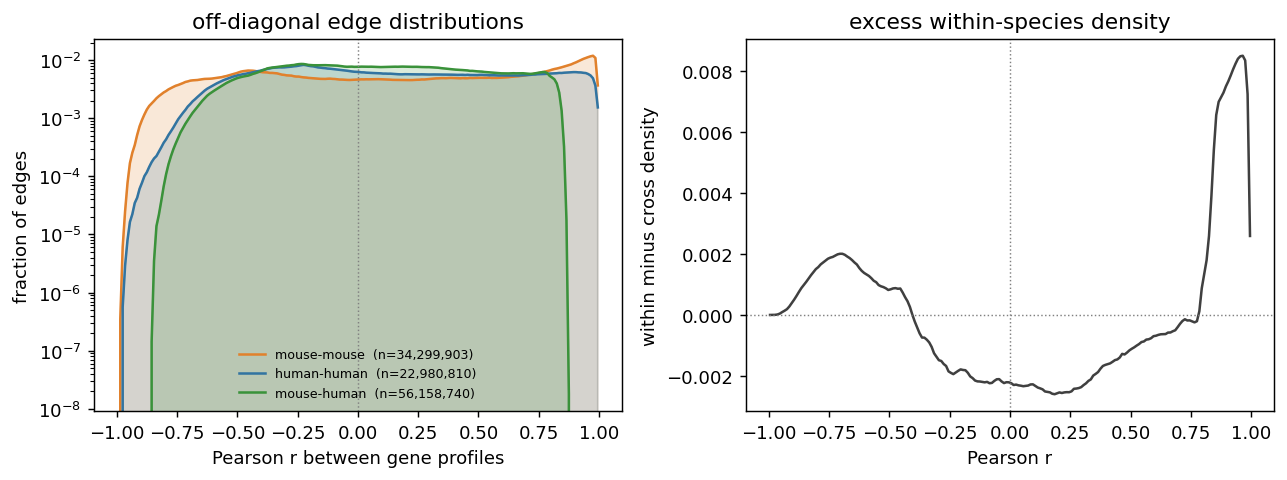

In [15]:
C, ed = profile_correlation(prof)     # C is (n_genes, n_genes) float32
plot_edges(ed)
ed.stats

In [16]:
def neighbor_similarity_summary(
    C, split, ks=(10, 25, 50, 100), block=256
):
    n = C.shape[0]
    records = []

    for source, start, stop in [
        ("mouse", 0, split),
        ("human", split, n),
    ]:
        for kind in ("within", "cross"):
            if (source == "mouse") == (kind == "within"):
                lo, hi = 0, split
            else:
                lo, hi = split, n

            max_neighbors = hi - lo - (kind == "within")
            valid_ks = [k for k in ks if k <= max_neighbors]
            if not valid_ks:
                continue

            kth_indices = np.array(valid_ks) - 1
            collected = []

            for s in range(start, stop, block):
                e = min(s + block, stop)
                values = np.array(C[s:e, lo:hi], dtype=float, copy=True)
                values[~np.isfinite(values)] = -np.inf

                if kind == "within":
                    values[np.arange(e - s), np.arange(s, e) - lo] = -np.inf

                # Partition negative similarities to obtain kth-largest values.
                values *= -1
                values.partition(kth_indices, axis=1)
                selected = -values[:, kth_indices]
                selected[~np.isfinite(selected)] = np.nan
                collected.append(selected)

            scores = np.vstack(collected)

            for j, k in enumerate(valid_ks):
                finite = scores[:, j][np.isfinite(scores[:, j])]
                quantiles = (
                    np.quantile(finite, [0.1, 0.25, 0.5, 0.75, 0.9])
                    if finite.size else np.full(5, np.nan)
                )
                records.append({
                    "source": source,
                    "edge_type": kind,
                    "k": k,
                    "valid_fraction": len(finite) / len(scores),
                    **dict(zip(
                        ["p10", "p25", "median", "p75", "p90"],
                        quantiles,
                    )),
                })

    return pd.DataFrame(records)

# Your pipeline orders mouse first, then human.
neighbor_summary = neighbor_similarity_summary(
    C, split=prof.meta["width_a"]
)
display(neighbor_summary.round(3))

,source,edge_type,k,valid_fraction,p10,p25,median,p75,p90
0,mouse,within,10,1.0,0.916,0.960,0.981,0.990,0.995
1,mouse,within,25,1.0,0.886,0.948,0.976,0.988,0.993
2,mouse,within,50,1.0,0.843,0.933,0.970,0.985,0.992
3,mouse,within,100,1.0,0.797,0.916,0.961,0.981,0.990
4,mouse,cross,10,1.0,0.635,0.722,0.781,0.816,0.838
5,mouse,cross,25,1.0,0.604,0.698,0.771,0.809,0.835
6,mouse,cross,50,1.0,0.573,0.678,0.760,0.802,0.833
7,mouse,cross,100,1.0,0.540,0.654,0.746,0.794,0.829
8,human,within,10,1.0,0.876,0.938,0.970,0.984,0.991
9,human,within,25,1.0,0.840,0.919,0.961,0.979,0.989


### Graph Construction and Clustering


In [22]:
"""
crossspecies_graph.py — build a gene graph with separate within- and
cross-dataset edge budgets.

    G = dual_knn_graph(C, split=prof.meta["width_a"], k_intra=15, k_inter=5)
    G.summary()
    labels = G.leiden(resolution=1.0)

Each gene proposes its top `k_intra` partners from its own dataset and its top
`k_inter` from the other, then proposals are symmetrized. Separating the budgets
is what lets the cross-species edges exist at all: a plain top-k graph on these
profiles fills every slot with same-species partners, because within-dataset
correlations have far heavier tails than cross-dataset ones.
"""

from __future__ import annotations

from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from scipy import sparse


@dataclass
class DualGraph:
    adj: sparse.csr_matrix              # symmetric, weights = Pearson r
    species: np.ndarray                 # per-node dataset label
    genes: np.ndarray | None = None
    meta: dict = field(default_factory=dict)

    @property
    def n_nodes(self) -> int:
        return self.adj.shape[0]

    def edge_frame(self) -> pd.DataFrame:
        """Upper-triangle edge list with a within/cross tag."""
        A = sparse.triu(self.adj, k=1).tocoo()
        same = self.species[A.row] == self.species[A.col]
        df = pd.DataFrame({
            "i": A.row, "j": A.col, "weight": A.data,
            "kind": np.where(same, "within", "cross"),
        })
        if self.genes is not None:
            df["gene_i"] = self.genes[A.row]
            df["gene_j"] = self.genes[A.col]
        return df

    def to_csv(
        self,
        path: str,
        nodes_path: str | None = None,
        labels: np.ndarray | None = None,
        float_format: str = "%.6g",
        index_cols: bool = False,
        verbose: bool = True,
    ) -> str:
        """Write the edge list to CSV (one row per undirected edge).

        Columns: source, target, weight, kind — plus source_species /
        target_species, and cluster columns when `labels` is given. Cytoscape,
        Gephi, and igraph's read_ncol all accept this layout.

        A path ending in .gz / .zst is compressed automatically by pandas.
        `index_cols=True` keeps the integer node indices alongside the names,
        which is what you want if you plan to read the graph back and line it up
        against the correlation matrix.
        """
        df = self.edge_frame()
        if self.genes is not None:
            out = pd.DataFrame({
                "source": df.gene_i, "target": df.gene_j,
                "weight": df.weight, "kind": df.kind,
                "source_species": self.species[df.i],
                "target_species": self.species[df.j],
            })
        else:
            out = pd.DataFrame({
                "source": df.i, "target": df.j,
                "weight": df.weight, "kind": df.kind,
                "source_species": self.species[df.i],
                "target_species": self.species[df.j],
            })
        if index_cols:
            out.insert(2, "source_idx", df.i.values)
            out.insert(3, "target_idx", df.j.values)
        if labels is not None:
            labels = np.asarray(labels)
            out["source_cluster"] = labels[df.i]
            out["target_cluster"] = labels[df.j]
            out["same_cluster"] = out.source_cluster == out.target_cluster

        out.to_csv(path, index=False, float_format=float_format)
        written = [path]

        if nodes_path is not None:
            nodes = self.degrees()
            if labels is not None:
                nodes["cluster"] = labels
            nodes.insert(0, "node_idx", np.arange(self.n_nodes))
            nodes.to_csv(nodes_path, index=False, float_format=float_format)
            written.append(nodes_path)

        if verbose:
            n_cross = int((out.kind == "cross").sum())
            print(f"wrote {len(out):,} edges ({n_cross:,} cross) -> {path}"
                  + (f"\n      {self.n_nodes:,} nodes -> {nodes_path}"
                     if nodes_path else ""))
        return path

    def degrees(self) -> pd.DataFrame:
        """Per-node within / cross degree."""
        A = self.adj.tocoo()
        same = self.species[A.row] == self.species[A.col]
        within = np.bincount(A.row[same], minlength=self.n_nodes)
        cross = np.bincount(A.row[~same], minlength=self.n_nodes)
        return pd.DataFrame({
            "gene": self.genes if self.genes is not None else np.arange(self.n_nodes),
            "species": self.species,
            "deg_within": within, "deg_cross": cross,
            "deg_total": within + cross,
            "frac_cross": cross / np.maximum(within + cross, 1),
        })

    def summary(self) -> None:
        d = self.degrees()
        A = sparse.triu(self.adj, k=1).tocoo()
        same = self.species[A.row] == self.species[A.col]
        print(f"{self.n_nodes:,} nodes | {A.nnz:,} edges "
              f"({same.sum():,} within, {(~same).sum():,} cross)")
        print(f"  isolated nodes        : {(d.deg_total == 0).sum():,}")
        print(f"  nodes with 0 cross    : {(d.deg_cross == 0).sum():,} "
              f"({(d.deg_cross == 0).mean():.1%})")
        print(f"  median degree         : within {d.deg_within.median():.0f}, "
              f"cross {d.deg_cross.median():.0f}")
        if A.nnz:
            print(f"  mean weight           : within {A.data[same].mean():.3f}, "
                  f"cross {A.data[~same].mean():.3f}")
        sat = self.meta.get("saturated")
        if sat:
            for tag in ("intra", "inter"):
                k = self.meta.get(f"k_{tag}")
                cut = self.meta.get(f"cutoff_{tag}")
                if k is None:
                    print(f"  {tag:<5} constraint     : cutoff {cut} only")
                else:
                    print(f"  {tag:<5} constraint     : k={k}"
                          + (f", cutoff {cut} — k binding for "
                             f"{sat[tag]:,}/{self.n_nodes:,} genes" if cut is not None
                             else " (no cutoff)"))
        n_comp, lab = sparse.csgraph.connected_components(self.adj, directed=False)
        sizes = np.bincount(lab)
        print(f"  connected components  : {n_comp:,} (largest {sizes.max():,})")

    def to_igraph(self, weight_mode: str = "raw", cross_boost: float = 1.0):
        """Build the igraph object, optionally rebalancing edge weights.

        weight_mode
            "raw"   weights are the Pearson r as stored.
            "rank"  weights are replaced by within-class percentile ranks, so
                    within- and cross-dataset edges are placed on a common
                    scale. Use this when cross edges are real but numerically
                    smaller and so never influence community structure.
            "boost" raw weights with cross-dataset edges multiplied by
                    `cross_boost`.
        """
        import igraph as ig

        A = sparse.triu(self.adj, k=1).tocoo()
        w = A.data.astype(float).copy()
        cross = self.species[A.row] != self.species[A.col]

        if weight_mode == "rank":
            for m in (cross, ~cross):
                if m.sum() > 1:
                    r = np.argsort(np.argsort(w[m]))
                    w[m] = (r + 1) / (m.sum() + 1)
        elif weight_mode == "boost":
            w[cross] *= cross_boost
        elif weight_mode != "raw":
            raise ValueError(f"unknown weight_mode {weight_mode!r}")

        g = ig.Graph(n=self.n_nodes, edges=list(zip(A.row.tolist(), A.col.tolist())))
        g.es["weight"] = w.tolist()
        g.vs["species"] = list(self.species)
        if self.genes is not None:
            g.vs["name"] = list(self.genes)
        return g

    def community(
        self,
        method: str = "leiden",
        resolution: float = 1.0,
        weight_mode: str = "raw",
        cross_boost: float = 1.0,
        objective: str = "modularity",
        n_iterations: int = -1,
        seed: int = 0,
        verbose: bool = True,
    ) -> np.ndarray:
        """Community detection using igraph's own algorithms (no leidenalg).

        method
            leiden, louvain (multilevel), infomap, walktrap, fastgreedy,
            leading_eigenvector, label_propagation
        """
        import igraph as ig
        import random

        random.seed(seed)
        g = self.to_igraph(weight_mode=weight_mode, cross_boost=cross_boost)
        w = g.es["weight"]

        if method == "leiden":
            vc = g.community_leiden(objective_function=objective, weights=w,
                                    resolution=resolution, n_iterations=n_iterations)
        elif method in ("louvain", "multilevel"):
            vc = g.community_multilevel(weights=w, resolution=resolution)
        elif method == "infomap":
            vc = g.community_infomap(edge_weights=w)
        elif method == "walktrap":
            vc = g.community_walktrap(weights=w).as_clustering()
        elif method == "fastgreedy":
            vc = g.community_fastgreedy(weights=w).as_clustering()
        elif method == "leading_eigenvector":
            vc = g.community_leading_eigenvector(weights=w)
        elif method == "label_propagation":
            vc = g.community_label_propagation(weights=w)
        else:
            raise ValueError(f"unknown method {method!r}")

        labels = np.asarray(vc.membership)
        if verbose:
            sizes = np.bincount(labels)
            mix = self.mixing(labels)
            print(f"{method}: {len(sizes)} communities, "
                  f"largest {sizes.max():,}, singletons {(sizes == 1).sum():,}")
            print(f"  modularity {g.modularity(labels, weights=w):.4f} | "
                  f"mean frac_minor {mix.frac_minor.mean():.3f} | "
                  f"mixed communities {(mix.frac_minor > 0.05).sum()}/{len(mix)}")
        return labels

    def compare_methods(self, methods=None, **kw) -> pd.DataFrame:
        """Run several igraph community algorithms and tabulate the outcomes."""
        methods = methods or ["leiden", "louvain", "infomap", "walktrap",
                              "fastgreedy", "leading_eigenvector",
                              "label_propagation"]
        rows = {}
        for m in methods:
            try:
                lab = self.community(m, verbose=False, **kw)
            except Exception as e:
                rows[m] = dict(n_comm=np.nan, note=f"{type(e).__name__}: {e}")
                continue
            mix = self.mixing(lab)
            sizes = np.bincount(lab)
            rows[m] = dict(
                n_comm=len(sizes), largest=int(sizes.max()),
                singletons=int((sizes == 1).sum()),
                mean_frac_minor=round(float(mix.frac_minor.mean()), 4),
                mixed=f"{int((mix.frac_minor > 0.05).sum())}/{len(mix)}",
                note="",
            )
            self._last = getattr(self, "_last", {})
            self._last[m] = lab
        return pd.DataFrame(rows).T

    def leiden(self, resolution: float = 1.0, seed: int = 0, **kw) -> np.ndarray:
        """Back-compat wrapper; now routed through igraph."""
        return self.community("leiden", resolution=resolution, seed=seed, **kw)

    def mixing(self, labels: np.ndarray) -> pd.DataFrame:
        """Per-cluster species composition."""
        a = self.meta.get("name_a", np.unique(self.species)[0])
        df = pd.DataFrame({"cluster": labels, "species": self.species})
        out = df.pivot_table(index="cluster", columns="species",
                             aggfunc="size", fill_value=0)
        out["n"] = out.sum(axis=1)
        out["frac_minor"] = out.drop(columns="n").min(axis=1) / out["n"]
        return out.sort_values("n", ascending=False)


def dual_knn_graph(
    C: np.ndarray,
    split,
    k_intra: int | None = 15,
    k_inter: int | None = 5,
    *,
    cutoff_intra: float | None = None,
    cutoff_inter: float | None = None,
    min_intra: float | None = None,   # deprecated aliases
    min_inter: float | None = None,
    max_edges: int = 50_000_000,
    mutual_inter: bool = False,
    mutual_intra: bool = False,
    genes: np.ndarray | None = None,
    species: np.ndarray | None = None,
    block: int = 2048,
    verbose: bool = True,
) -> DualGraph:
    """Top-k_intra same-dataset and top-k_inter other-dataset edges per gene.

    split
        Either an int (first `split` rows are dataset A) or a boolean/label array
        of length n marking dataset membership.

    k_intra / k_inter
        Per-gene edge budgets. Pass None to drop the budget and keep every edge
        clearing the corresponding cutoff (a pure threshold graph). At least one
        of k or cutoff must be set for each edge class.

    cutoff_intra / cutoff_inter
        Correlation cutoffs, applied per edge class. With a k budget they act as
        a floor: a gene takes its top-k partners but only those clearing the
        cutoff, so a gene with no good partner gets no edge. Without them every
        gene is *forced* to accept k_inter cross-dataset partners no matter how
        weak, which manufactures integration — the graph looks mixed because the
        construction guaranteed it, not because the genes resemble each other.
        Pick values from the cross-dataset tail in profile_correlation's stats
        (frac_gt_0_3 / frac_gt_0_5) rather than by eye.

        `min_intra` / `min_inter` are accepted as deprecated aliases.

    mutual_inter / mutual_intra
        Keep an edge only when both endpoints proposed it. Recommended for the
        cross set — it removes hub genes that appear in everyone's top-k while
        nominating someone else.
    """
    C = np.asarray(C)
    n = C.shape[0]
    if C.ndim != 2 or C.shape[1] != n:
        raise ValueError(f"C must be square, got {C.shape}")

    if min_intra is not None:
        cutoff_intra = min_intra if cutoff_intra is None else cutoff_intra
    if min_inter is not None:
        cutoff_inter = min_inter if cutoff_inter is None else cutoff_inter
    for tag, k, cut in (("intra", k_intra, cutoff_intra), ("inter", k_inter, cutoff_inter)):
        if k is None and cut is None:
            raise ValueError(f"set k_{tag} or cutoff_{tag} (both None keeps everything)")

    if np.isscalar(split):
        is_a = np.arange(n) < int(split)
    else:
        split = np.asarray(split)
        is_a = split.astype(bool) if split.dtype == bool else split == np.unique(split)[0]
    if species is None:
        species = np.where(is_a, "A", "B")
    species = np.asarray(species)

    rows_i, cols_i, w_i = [], [], []     # intra proposals
    rows_x, cols_x, w_x = [], [], []     # inter proposals

    saturated = {"intra": 0, "inter": 0}     # genes whose k budget was binding

    def _topk(blk, mask_cols, k, floor, tag=None):
        """Top-k columns per row within mask_cols, and/or everything over floor."""
        if not mask_cols.any() or (k is not None and k <= 0):
            return None
        cand = np.flatnonzero(mask_cols)
        sub = blk[:, cand]

        if k is None:                         # pure threshold: no per-gene budget
            rr, cj = np.where(sub >= floor)
            ww = sub[rr, cj]
            if len(rr) > max_edges:
                raise MemoryError(
                    f"{len(rr):,} {tag} edges above {floor} in one block; "
                    f"raise the cutoff or set k_{tag}")
            return rr, cand[cj], ww

        kk = min(k, sub.shape[1])
        part = np.argpartition(-sub, kk - 1, axis=1)[:, :kk]
        wv = np.take_along_axis(sub, part, 1)
        order = np.argsort(-wv, axis=1)
        part = np.take_along_axis(part, order, 1)
        wv = np.take_along_axis(wv, order, 1)
        rr = np.repeat(np.arange(sub.shape[0]), kk)
        cc = cand[part.ravel()]
        ww = wv.ravel()
        keep = np.isfinite(ww)
        if floor is not None:
            keep &= ww >= floor
            if tag is not None:               # k was binding for this gene
                per_gene = keep.reshape(sub.shape[0], kk).sum(1)
                saturated[tag] += int((per_gene == kk).sum())
        elif tag is not None:
            saturated[tag] += sub.shape[0]
        return rr[keep], cc[keep], ww[keep]

    for s in range(0, n, block):
        e = min(s + block, n)
        blk = np.array(C[s:e], dtype=np.float64)
        blk[np.arange(e - s), np.arange(s, e)] = -np.inf      # no self edges
        rows_here = np.arange(s, e)

        for side in (True, False):
            rmask = is_a[s:e] == side
            if not rmask.any():
                continue
            sub = blk[rmask]
            same_cols, other_cols = (is_a, ~is_a) if side else (~is_a, is_a)

            got = _topk(sub, same_cols, k_intra, cutoff_intra, "intra")
            if got is not None:
                rr, cc, ww = got
                rows_i.append(rows_here[rmask][rr]); cols_i.append(cc); w_i.append(ww)

            got = _topk(sub, other_cols, k_inter, cutoff_inter, "inter")
            if got is not None:
                rr, cc, ww = got
                rows_x.append(rows_here[rmask][rr]); cols_x.append(cc); w_x.append(ww)

    def _build(rows, cols, ws, mutual):
        if not rows:
            return sparse.csr_matrix((n, n))
        r = np.concatenate(rows); c = np.concatenate(cols); w = np.concatenate(ws)
        P = sparse.csr_matrix((w, (r, c)), shape=(n, n))     # directed proposals
        P.sum_duplicates()
        if mutual:
            both = P.multiply(P.T != 0)
            A = both.maximum(both.T)
        else:
            A = P.maximum(P.T)
        return A.tocsr()

    A_intra = _build(rows_i, cols_i, w_i, mutual_intra)
    A_inter = _build(rows_x, cols_x, w_x, mutual_inter)
    adj = (A_intra.maximum(A_inter)).tocsr()
    adj.setdiag(0)
    adj.eliminate_zeros()

    G = DualGraph(adj=adj, species=species, genes=genes,
                  meta=dict(k_intra=k_intra, k_inter=k_inter,
                            cutoff_intra=cutoff_intra, cutoff_inter=cutoff_inter,
                            saturated=dict(saturated),
                            mutual_intra=mutual_intra, mutual_inter=mutual_inter,
                            n_a=int(is_a.sum()), n_b=int((~is_a).sum()),
                            name_a=str(species[is_a][0]) if is_a.any() else "A",
                            name_b=str(species[~is_a][0]) if (~is_a).any() else "B"))
    if verbose:
        G.summary()
    return G

### Hyperparameter Search

In [23]:
"""Cached positive-edge graph search; no single score establishes biological quality."""
from itertools import product, combinations
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.metrics import adjusted_rand_score

PARAMS = ('k_intra', 'k_inter', 'cutoff_intra', 'cutoff_inter')


def cache_neighbors(C, split, max_intra=100, max_inter=50, block=256):
    """Scan C once; retain ranked proposals up to the largest requested budgets."""
    n = C.shape[0]
    if C.shape != (n, n) or not 0 < split < n:
        raise ValueError('Expected a square C and an interior integer split')
    if block < 1 or min(max_intra, max_inter) < 1:
        raise ValueError('Block and budgets must be positive')
    side = np.arange(n) < split
    cache = {'split': split, 'n': n}
    for kind, budget in [('intra', max_intra), ('inter', max_inter)]:
        cache[kind] = (np.full((n, budget), -1, dtype=np.int32),
                       np.full((n, budget), -np.inf, dtype=np.float32))
    for s in range(0, n, block):
        rows = np.arange(s, min(s + block, n))
        for a in (True, False):
            rr = rows[side[rows] == a]
            if not len(rr):
                continue
            for kind in ('intra', 'inter'):
                cols = np.flatnonzero(side == (a if kind == 'intra' else not a))
                dest, weights = cache[kind]
                k = min(dest.shape[1], len(cols))
                x = np.array(C[np.ix_(rr, cols)], dtype=np.float64)
                x[~np.isfinite(x)] = -np.inf
                if kind == 'intra':
                    x[np.arange(len(rr)), np.searchsorted(cols, rr)] = -np.inf
                ix = np.argpartition(-x, k - 1, axis=1)[:, :k]
                w = np.take_along_axis(x, ix, axis=1)
                order = np.argsort(-w, axis=1, kind='stable')
                ix = np.take_along_axis(ix, order, axis=1)
                dest[rr, :k] = cols[ix]
                weights[rr, :k] = np.take_along_axis(w, order, axis=1)
    return cache


def cached_graph(cache, genes, species, k_intra, k_inter,
                 cutoff_intra, cutoff_inter):
    """Same union symmetrization as dual_knn_graph's default, positive edges only.

    Exact ties at the budget boundary may select different equally weighted partners.
    """
    n = cache['n']
    species = np.asarray(species)
    genes = np.asarray(genes)
    if len(species) != n or len(genes) != n:
        raise ValueError('Gene/species lengths must match the cache')
    split = cache['split']
    if (len(set(species[:split])) != 1 or len(set(species[split:])) != 1
            or species[0] == species[-1]):
        raise ValueError('Species must follow the two contiguous cache blocks')
    adj = sparse.csr_matrix((n, n))
    for kind, k, cut in [('intra', k_intra, cutoff_intra),
                         ('inter', k_inter, cutoff_inter)]:
        cols, weights = cache[kind]
        if not 1 <= k <= cols.shape[1] or not 0 < cut <= 1:
            raise ValueError('Budgets must fit cache; cutoffs must be in (0, 1]')
        w = weights[:, :k]
        r, j = np.where(np.isfinite(w) & (w >= cut))
        p = sparse.csr_matrix((w[r, j], (r, cols[r, j])), shape=(n, n))
        adj = adj + p.maximum(p.T)
    return DualGraph(adj, species, genes,
                     meta={'name_a': str(species[0]), 'name_b': str(species[-1])})


def diagnostics(G, labels):
    A = G.adj
    d = G.degrees()
    strength = np.asarray(A.sum(axis=1)).ravel()
    coo = A.tocoo()
    cross = G.species[coo.row] != G.species[coo.col]
    xs = np.bincount(coo.row[cross], weights=coo.data[cross], minlength=G.n_nodes)
    nc, components = sparse.csgraph.connected_components(A, directed=False)
    sizes = np.bincount(labels)
    mixed = G.mixing(labels)
    out = dict(n_edges=A.nnz // 2, n_components=nc,
               largest_component_frac=np.bincount(components).max() / G.n_nodes,
               n_modules=len(sizes), largest_module_frac=sizes.max() / G.n_nodes,
               singleton_gene_frac=np.sum(sizes == 1) / G.n_nodes,
               cross_weight_frac=xs.sum() / max(strength.sum(), 1e-12),
               mixed_module_frac=float((mixed.frac_minor > 0.05).mean()))
    for name in np.unique(G.species):
        m = G.species == name
        out.update({f'{name}_isolated_frac': float((d.deg_total.to_numpy()[m] == 0).mean()),
                    f'{name}_cross_coverage': float((d.deg_cross.to_numpy()[m] > 0).mean()),
                    f'{name}_median_degree': float(np.median(d.deg_total.to_numpy()[m])),
                    f'{name}_p95_degree': float(np.quantile(d.deg_total.to_numpy()[m], .95)),
                    f'{name}_median_cross_strength_frac': float(np.median(xs[m] / np.maximum(strength[m], 1e-12)))})
    return out


def screen(cache, genes, species, grid, outdir, resolution=1.0, seed=0):
    """Run fixed-seed screen, checkpoint summaries and labels after each graph.

    Use a fresh directory per run to avoid mixing configurations/results.
    """
    out = Path(outdir)
    out.mkdir(parents=True, exist_ok=False)
    (out / 'configuration.json').write_text(json.dumps(dict(
        grid=grid, resolution=resolution, seed=seed,
        weight_mode='raw', mutual_intra=False, mutual_inter=False), indent=2))
    pd.DataFrame({'gene': genes, 'species': species}).to_csv(out / 'nodes.csv', index=False)
    records = []
    settings = list(product(*(grid[p] for p in PARAMS)))
    for i, vals in enumerate(settings):
        params = dict(zip(PARAMS, vals))
        G = cached_graph(cache, genes, species, **params)
        labels = G.leiden(resolution=resolution, seed=seed, verbose=False)
        np.save(out / f'labels_{i:03d}.npy', labels)
        records.append(dict(run_id=i, **params, **diagnostics(G, labels)))
        pd.DataFrame(records).to_csv(out / 'screen.csv', index=False)
        print(f'{i + 1}/{len(settings)}: {params} -> {len(np.unique(labels))} modules', flush=True)
    return pd.DataFrame(records)


def stability(cache, genes, species, shortlist, outdir, seeds=range(5),
              resolutions=(0.5, 1.0, 1.5)):
    """Seed ARI per setting/resolution; compare all genes and nonisolated genes."""
    out = Path(outdir)
    out.mkdir(parents=True, exist_ok=False)
    seeds = list(seeds)
    if len(seeds) < 2:
        raise ValueError('At least two seeds are needed')
    records = []
    for _, row in shortlist.iterrows():
        params = {p: int(row[p]) if p.startswith('k_') else float(row[p]) for p in PARAMS}
        G = cached_graph(cache, genes, species, **params)
        active = np.asarray(G.adj.getnnz(axis=1)) > 0
        for resolution in resolutions:
            labs = [G.leiden(resolution=resolution, seed=int(s), verbose=False) for s in seeds]
            np.savez_compressed(out / f'run_{int(row.run_id):03d}_resolution_{resolution}.npz',
                                labels=np.stack(labs), seeds=seeds)
            aris = [adjusted_rand_score(a, b) for a, b in combinations(labs, 2)]
            active_aris = [adjusted_rand_score(a[active], b[active])
                           for a, b in combinations(labs, 2)] if active.sum() > 1 else [np.nan]
            records.append(dict(run_id=int(row.run_id), **params, resolution=resolution,
                                mean_seed_ari=np.mean(aris), min_seed_ari=np.min(aris),
                                mean_active_seed_ari=np.mean(active_aris),
                                min_active_seed_ari=np.min(active_aris),
                                **diagnostics(G, labs[0])))
            pd.DataFrame(records).to_csv(out / 'stability.csv', index=False)
    return pd.DataFrame(records)


def adjacent_agreement(results, outdir):
    """ARI between grid neighbors differing by one step in one parameter."""
    levels = {p: sorted(results[p].unique()) for p in PARAMS}
    records = []
    labels = {int(r): np.load(Path(outdir) / f'labels_{int(r):03d}.npy') for r in results.run_id}
    for (_, a), (_, b) in combinations(results.iterrows(), 2):
        changed = [p for p in PARAMS if a[p] != b[p]]
        if len(changed) != 1:
            continue
        p = changed[0]
        if abs(levels[p].index(a[p]) - levels[p].index(b[p])) != 1:
            continue
        records.append(dict(run_a=int(a.run_id), run_b=int(b.run_id), parameter=p,
                            ari=adjusted_rand_score(labels[int(a.run_id)], labels[int(b.run_id)])))
    return pd.DataFrame(records, columns=['run_a', 'run_b', 'parameter', 'ari'])


### Joint-Network Hyperparameter Search


In [24]:
from pathlib import Path
from datetime import datetime

assert prof.meta['n_ortho'] == res.n_orthologs, (
    "Rebuild prof = stitch_profiles(res), then C, using the actual ortholog count."
)
assert C.shape == (len(prof.genes), len(prof.genes))

grid = dict(
    k_intra=[25, 50, 100],
    k_inter=[10, 25, 50],
    cutoff_intra=[0.85, 0.90, 0.95],
    cutoff_inter=[0.65, 0.70, 0.75],
)
neighbor_cache = cache_neighbors(
    C, prof.meta['width_a'],
    max_intra=max(grid['k_intra']), max_inter=max(grid['k_inter']),
)
search_dir = Path('hyperparameter_results') / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
results = screen(neighbor_cache, prof.genes, prof.species, grid, search_dir)
display(results)


1/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.85, 'cutoff_inter': 0.65} -> 202 modules
2/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.85, 'cutoff_inter': 0.7} -> 233 modules
3/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.85, 'cutoff_inter': 0.75} -> 236 modules
4/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.9, 'cutoff_inter': 0.65} -> 399 modules
5/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.9, 'cutoff_inter': 0.7} -> 538 modules
6/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.9, 'cutoff_inter': 0.75} -> 617 modules
7/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.95, 'cutoff_inter': 0.65} -> 747 modules
8/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.95, 'cutoff_inter': 0.7} -> 1091 modules
9/81: {'k_intra': 25, 'k_inter': 10, 'cutoff_intra': 0.95, 'cutoff_inter': 0.75} -> 1493 modules
10/81: {'k_intra': 25, 'k_inter': 25, 'cutoff_intra': 0.85, 'cutoff_inter': 0.65} -> 199 modules
11/81: {'k_intra': 25, 'k_inter': 25, 'cuto

,run_id,k_intra,k_inter,cutoff_intra,cutoff_inter,n_edges,n_components,largest_component_frac,n_modules,largest_module_frac,...,human_isolated_frac,human_cross_coverage,human_median_degree,human_p95_degree,human_median_cross_strength_frac,mouse_isolated_frac,mouse_cross_coverage,mouse_median_degree,mouse_p95_degree,mouse_median_cross_strength_frac
0,0,25,10,0.85,0.65,394102,184,0.985262,202,0.114453,...,0.017404,0.893068,46.0,100.00,0.194829,0.006036,0.918025,47.0,87.0,0.193845
1,1,25,10,0.85,0.70,385377,211,0.982938,233,0.105424,...,0.019027,0.844100,45.5,98.00,0.183740,0.007244,0.883859,46.0,86.0,0.184946
2,2,25,10,0.85,0.75,362477,214,0.982739,236,0.108544,...,0.019469,0.725369,43.0,92.05,0.151245,0.007244,0.793795,45.0,82.0,0.164205
3,3,25,10,0.90,0.65,376780,377,0.970524,399,0.106752,...,0.032596,0.893068,44.5,99.00,0.201950,0.015091,0.918025,46.0,86.0,0.197864
4,4,25,10,0.90,0.70,368055,513,0.958840,538,0.102569,...,0.043510,0.844100,44.0,97.00,0.189977,0.020283,0.883859,46.0,86.0,0.188708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,100,50,0.90,0.70,1366272,513,0.958840,536,0.143398,...,0.043510,0.844100,173.0,430.05,0.241025,0.020283,0.883859,184.0,341.0,0.233705
77,77,100,50,0.90,0.75,1241576,594,0.951338,613,0.161854,...,0.050737,0.725369,153.0,393.00,0.149928,0.023542,0.793795,173.0,315.0,0.188831
78,78,100,50,0.95,0.65,1215687,724,0.941645,746,0.162982,...,0.063717,0.893068,147.0,422.05,0.391785,0.029337,0.918025,169.0,333.0,0.287561
79,79,100,50,0.95,0.70,1143586,1068,0.911571,1089,0.143597,...,0.091593,0.844100,129.0,401.05,0.314315,0.045153,0.883859,165.0,322.0,0.266818


In [ ]:
agreement = adjacent_agreement(results, search_dir)
agreement.to_csv(search_dir / 'adjacent_agreement.csv', index=False)
neighbor_ari = pd.concat([
    agreement[['run_a', 'ari']].rename(columns={'run_a': 'run_id'}),
    agreement[['run_b', 'ari']].rename(columns={'run_b': 'run_id'}),
]).groupby('run_id').ari.agg(['mean', 'min']).rename(
    columns={'mean': 'mean_adjacent_ari', 'min': 'min_adjacent_ari'}
)
review = results.join(neighbor_ari, on='run_id')
review.to_csv(search_dir / 'review.csv', index=False)
display(review.sort_values('mean_adjacent_ari', ascending=False))

# Parameter effects at the current baseline budgets, not an aggregate over k.
baseline_slice = review.query('k_intra == 50 and k_inter == 50')
for metric in ['n_modules', 'largest_module_frac', 'cross_weight_frac',
               'mouse_cross_coverage', 'human_cross_coverage']:
    if metric in baseline_slice:
        print(metric)
        display(baseline_slice.pivot(
            index='cutoff_intra', columns='cutoff_inter', values=metric
        ).round(3))


Select approximately 5–10 run IDs after reviewing coverage, module sizes, and nearby-setting agreement. Include the baseline and contrasting settings, rather than simply taking the highest ARI. Isolated nodes and trivial partitions can make all-gene ARI misleading; the next stage also reports ARI among nonisolated genes.

The following cell intentionally waits for a shortlist. Five seeds and three resolutions assess optimizer variability and resolution sensitivity; they do not replace spatial resampling or biological validation. Saved labels permit module-by-module inspection and later export of selected graphs.


In [ ]:
shortlist_ids = []  # Fill from review.run_id after inspecting the screen.
if shortlist_ids:
    shortlist = results[results.run_id.isin(shortlist_ids)]
    assert len(shortlist) == len(set(shortlist_ids)), "Unknown run ID"
    stability_dir = search_dir / ('stability_' + datetime.now().strftime('%H%M%S_%f'))
    stability_results = stability(
        neighbor_cache, prof.genes, prof.species, shortlist,
        stability_dir, seeds=range(5), resolutions=(0.5, 1.0, 1.5),
    )
    display(stability_results)
else:
    print('Inspect review, then choose shortlist_ids to run seed/resolution checks.')
